# Luật số lớn và Định lý giới hạn trung tâm

Notebook này mô phỏng và chứng minh thực nghiệm Luật số lớn (LLN) và Định lý giới hạn trung tâm (CLT) trên tập dữ liệu Wine Quality.

## Import & Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sys
import os
from IPython.display import Markdown, display

# Thêm đường dẫn source vào hệ thống
sys.path.append(os.path.abspath(".."))
from source.utils import (
    mean, variance, standard_deviation, covariance, correlation,
    simulate_lln, simulate_clt
)
from source.visualization import (
    distribution, dot_diagram, box_plot,
    plot_lln_convergence_grid, plot_clt_convergence_grid
)

%reload_ext autoreload
%autoreload 2

In [ ]:
# Tải dataset
df = pd.read_csv('../data/winequality-red.csv', sep=';')
features = df.drop(columns=['quality'])

display(Markdown(f"**Số lượng mẫu (samples):** $n = {df.shape[0]}$"))
display(Markdown(f"**Số lượng biến (features):** $p = {features.shape[1]}$"))
display(Markdown(f"**Danh sách các biến:** {', '.join(features.columns.tolist())}"))

**Số lượng mẫu (samples):** $n = 1599$

**Số lượng biến (features):** $p = 11$

**Danh sách các biến:** fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol

## 1. Chuẩn bị dữ liệu

Giai đoạn này chuẩn bị sẵn một số giá trị cần thiết để cần cho bước sau. Chưa đi sâu vào phân tích/mô phỏng.

In [ ]:
# Thống kê mô tả
display(Markdown("### Thống kê mô tả (đã phân tích ở notebook 1):"))
display(df.describe().round(4))

### Thống kê mô tả (đã phân tích ở notebook 1):

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000
mean,8.3196,0.5278,0.2710,2.5388,0.0875,15.8749,46.4678,0.9967,3.3111,0.6581,10.4230,5.6360
std,1.7411,0.1791,0.1948,1.4099,0.0471,10.4602,32.8953,0.0019,0.1544,0.1695,1.0657,0.8076
min,4.6000,0.1200,0.0000,0.9000,0.0120,1.0000,6.0000,0.9901,2.7400,0.3300,8.4000,3.0000
25%,7.1000,0.3900,0.0900,1.9000,0.0700,7.0000,22.0000,0.9956,3.2100,0.5500,9.5000,5.0000
50%,7.9000,0.5200,0.2600,2.2000,0.0790,14.0000,38.0000,0.9968,3.3100,0.6200,10.2000,6.0000
75%,9.2000,0.6400,0.4200,2.6000,0.0900,21.0000,62.0000,0.9978,3.4000,0.7300,11.1000,6.0000
max,15.9000,1.5800,1.0000,15.5000,0.6110,72.0000,289.0000,1.0037,4.0100,2.0000,14.9000,8.0000


In [ ]:
# Tính mu và sigma quần thể cho tất cả các biến
pop_params = pd.DataFrame({
    'Variable': features.columns,
    'Population Mean (μ)': [mean(features[col]) for col in features.columns],
    'Population Std Dev (σ)': [standard_deviation(features[col], is_population=True) for col in features.columns]
})

pop_means = dict(zip(pop_params['Variable'], pop_params['Population Mean (μ)']))
pop_stds = dict(zip(pop_params['Variable'], pop_params['Population Std Dev (σ)']))

display(Markdown("### Tham số quần thể:"))
display(pop_params)

### Tham số quần thể:

,Variable,Population Mean (μ),Population Std Dev (σ)
0,fixed acidity,8.319637,1.740552
1,volatile acidity,0.527821,0.179004
2,citric acid,0.270976,0.194740
3,residual sugar,2.538806,1.409487
4,chlorides,0.087467,0.047051
5,free sulfur dioxide,15.874922,10.456886
6,total sulfur dioxide,46.467792,32.885037
7,density,0.996747,0.001887
8,pH,3.311113,0.154338
9,sulphates,0.658149,0.169454


## 2. Law of Large Numbers - LLN

### 2.1 Tóm tắt lý thuyết
- **Phát biểu:** Cho dãy các biến ngẫu nhiên độc lập cùng phân phối (i.i.d) $X_1, X_2, ..., X_n$ có trung bình hữu hạn $E[X_i] = \mu$. Khi đó, trung bình mẫu $\bar{x}_n$ sẽ hội tụ theo xác suất về trung bình quần thể $\mu$:
  $$\bar{x}_n = \frac{1}{n} \sum_{i=1}^n X_i \rightarrow \mu \text{ khi } n \to \infty$$
- **Công thức sai số tương đối:** $\text{Error} = \frac{|\bar{x} - \mu|}{\mu}$

### 2.2 Ý tưởng mô phỏng

LLN phát biểu rằng $\bar{x}_n \rightarrow \mu$ khi $n \rightarrow \infty$. Để minh họa điều này, ta cần cho thấy **sai số giữa $\bar{x}_n$ và $\mu$ giảm dần khi $n$ tăng lên**.

Cụ thể, với mỗi giá trị $n$, ta tính $\bar{x}_n$ rồi đo sai số tương đối so với $\mu$ thật:

$$\text{Error}(n) = \frac{|\bar{x}_n - \mu|}{\mu}$$

Nếu LLN đúng, đường $\text{Error}(n)$ phải giảm dần về $0$ khi $n$ tăng.

---

**Tại sao phải shuffle trước khi tính?**

Dataset gốc không ngẫu nhiên — các mẫu có thể được sắp xếp theo một thứ tự nhất định. Nếu tính trực tiếp trên thứ tự gốc, $\bar{x}_n$ ở các $n$ nhỏ sẽ bị lệch do chỉ đại diện cho một nhóm mẫu có tính chất tương đồng, không phản ánh đúng quần thể. Shuffle ngẫu nhiên trước khi tính đảm bảo mỗi bước $n$ đều lấy mẫu đại diện.

Sau khi shuffle, ta tính **trung bình tích lũy**: tại mỗi bước $n$, lấy trung bình của $n$ phần tử đầu tiên trong dãy đã shuffle.

$$n = 1 \rightarrow \bar{x}_1 = x_{52}$$

$$n = 2 \rightarrow \bar{x}_2 = \frac{x_{52} + x_{3}}{2}$$

$$n = 3 \rightarrow \bar{x}_3 = \frac{x_{52} + x_{3} + x_{810}}{3}$$

$$\vdots$$

$$n = N \rightarrow \bar{x}_N \approx \mu$$

---

**Tại sao cần lặp 100 lần?**

Mỗi lần shuffle cho ra một thứ tự ngẫu nhiên khác nhau, dẫn đến một tập hợp các sai số khác nhau. Nếu chỉ chạy một lần, kết quả phụ thuộc vào may rủi của lần shuffle đó và không đại diện cho hành vi chung của LLN.

Lặp lại toàn bộ quá trình $100$ lần — mỗi lần shuffle khác nhau, mỗi lần cho ra một tập hợp các sai số — rồi tổng hợp lại. Kết quả thu được là **trung bình của $100$ tập hợp các sai số** cùng với **$95\%$ confidence band**, phản ánh hành vi thực sự của LLN thay vì một kịch bản ngẫu nhiên đơn lẻ.

---

#### Các bước thực hiện

**Bước 1 — Xác định các giá trị $n$ cần tính**

Thay vì tính tại mọi $n$ từ $1$ đến $1599$ (tốn thời gian), ta chọn các mốc cách đều với bước nhảy $20$:

$$n \in \{20, 40, 60, \ldots, 1599\}$$

**Bước 2 — Lặp 100 lần, mỗi lần shuffle toàn bộ dataset**

Dùng `np.random.permutation` để sinh ra một thứ tự chỉ số ngẫu nhiên mới rồi áp dụng lên dataset. Mỗi trial cho ra một dãy dữ liệu được xáo trộn độc lập.

**Bước 3 — Tính trung bình tích lũy bằng cumulative sum**

Thay vì tính `mean(data[:10])`, `mean(data[:30])`,... từng cái một trong một vòng lặp, ta dùng `np.cumsum` để tính tổng tích lũy toàn bộ dãy **một lần duy nhất**, sau đó lấy đúng các vị trí $n$ cần thiết rồi chia cho $n$:

$$\bar{x}_n = \frac{\text{cumsum}[n-1]}{n}$$

Cách này tránh được vòng lặp lồng nhau, nhanh hơn đáng kể.

**Bước 4 — Tính sai số tương đối tại mỗi $n$**

$$\text{Error}(n) = \frac{|\bar{x}_n - \mu|}{\mu}$$

Mỗi trial cho ra một mảng sai số có độ dài bằng số mốc $n$ đã chọn ở Bước 1.

**Bước 5 — Tổng hợp kết quả của 100 trial**

Xếp $100$ mảng sai số thành ma trận shape $(100, \, \text{len(sizes)})$, sau đó tính mean và std theo chiều trial:

$$\text{mean\_error}(n) = \frac{1}{100} \sum_{t=1}^{100} \text{Error}_t(n)$$

$$\text{band}(n) = \text{mean\_error}(n) \pm 1.96 \cdot \text{std\_error}(n)$$

In [ ]:
np.random.seed(42)
# Thực hiện mô phỏng LLN qua 100 lần chạy
all_trials_errors, sizes = simulate_lln(features, pop_means, n_trials=100, step=20)

display(Markdown(f"#### **Đã thực hiện 100 lần mô phỏng LLN.**"))

all_trials_errors_df = pd.DataFrame({
    col: np.mean(all_trials_errors[col], axis=0) for col in features.columns
}, index=sizes)
display(Markdown("#### Sai số trung bình sau 100 lần lặp của các biến theo mỗi kích thước mẫu:"))
display(all_trials_errors_df.round(6))

#### **Đã thực hiện 100 lần mô phỏng LLN.**

#### Sai số trung bình sau 100 lần lặp của các biến theo mỗi kích thước mẫu:

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
20,0.034164,0.064910,0.131471,0.098956,0.085690,0.121118,0.122455,0.000348,0.007937,0.045160,0.019248
40,0.024583,0.045347,0.095534,0.067820,0.061668,0.077260,0.071375,0.000248,0.006195,0.033290,0.013669
60,0.019240,0.035737,0.075261,0.055806,0.051864,0.065644,0.064535,0.000175,0.004503,0.028932,0.010035
80,0.016410,0.031010,0.060765,0.050141,0.053256,0.055568,0.054405,0.000158,0.003937,0.024953,0.009249
100,0.014904,0.026873,0.051820,0.045377,0.049939,0.052680,0.047324,0.000138,0.003602,0.020940,0.007858
...,...,...,...,...,...,...,...,...,...,...,...
1520,0.000899,0.001485,0.003521,0.002565,0.002264,0.002526,0.002676,0.000009,0.000233,0.001173,0.000426
1540,0.000775,0.001391,0.003038,0.002276,0.002057,0.002260,0.002196,0.000007,0.000197,0.000987,0.000375
1560,0.000629,0.001125,0.002482,0.001671,0.001850,0.001832,0.001953,0.000006,0.000166,0.000792,0.000310
1580,0.000401,0.000694,0.001531,0.001099,0.001286,0.001377,0.001363,0.000004,0.000106,0.000569,0.000199


### 2.4 Trực quan hóa hội tụ LLN

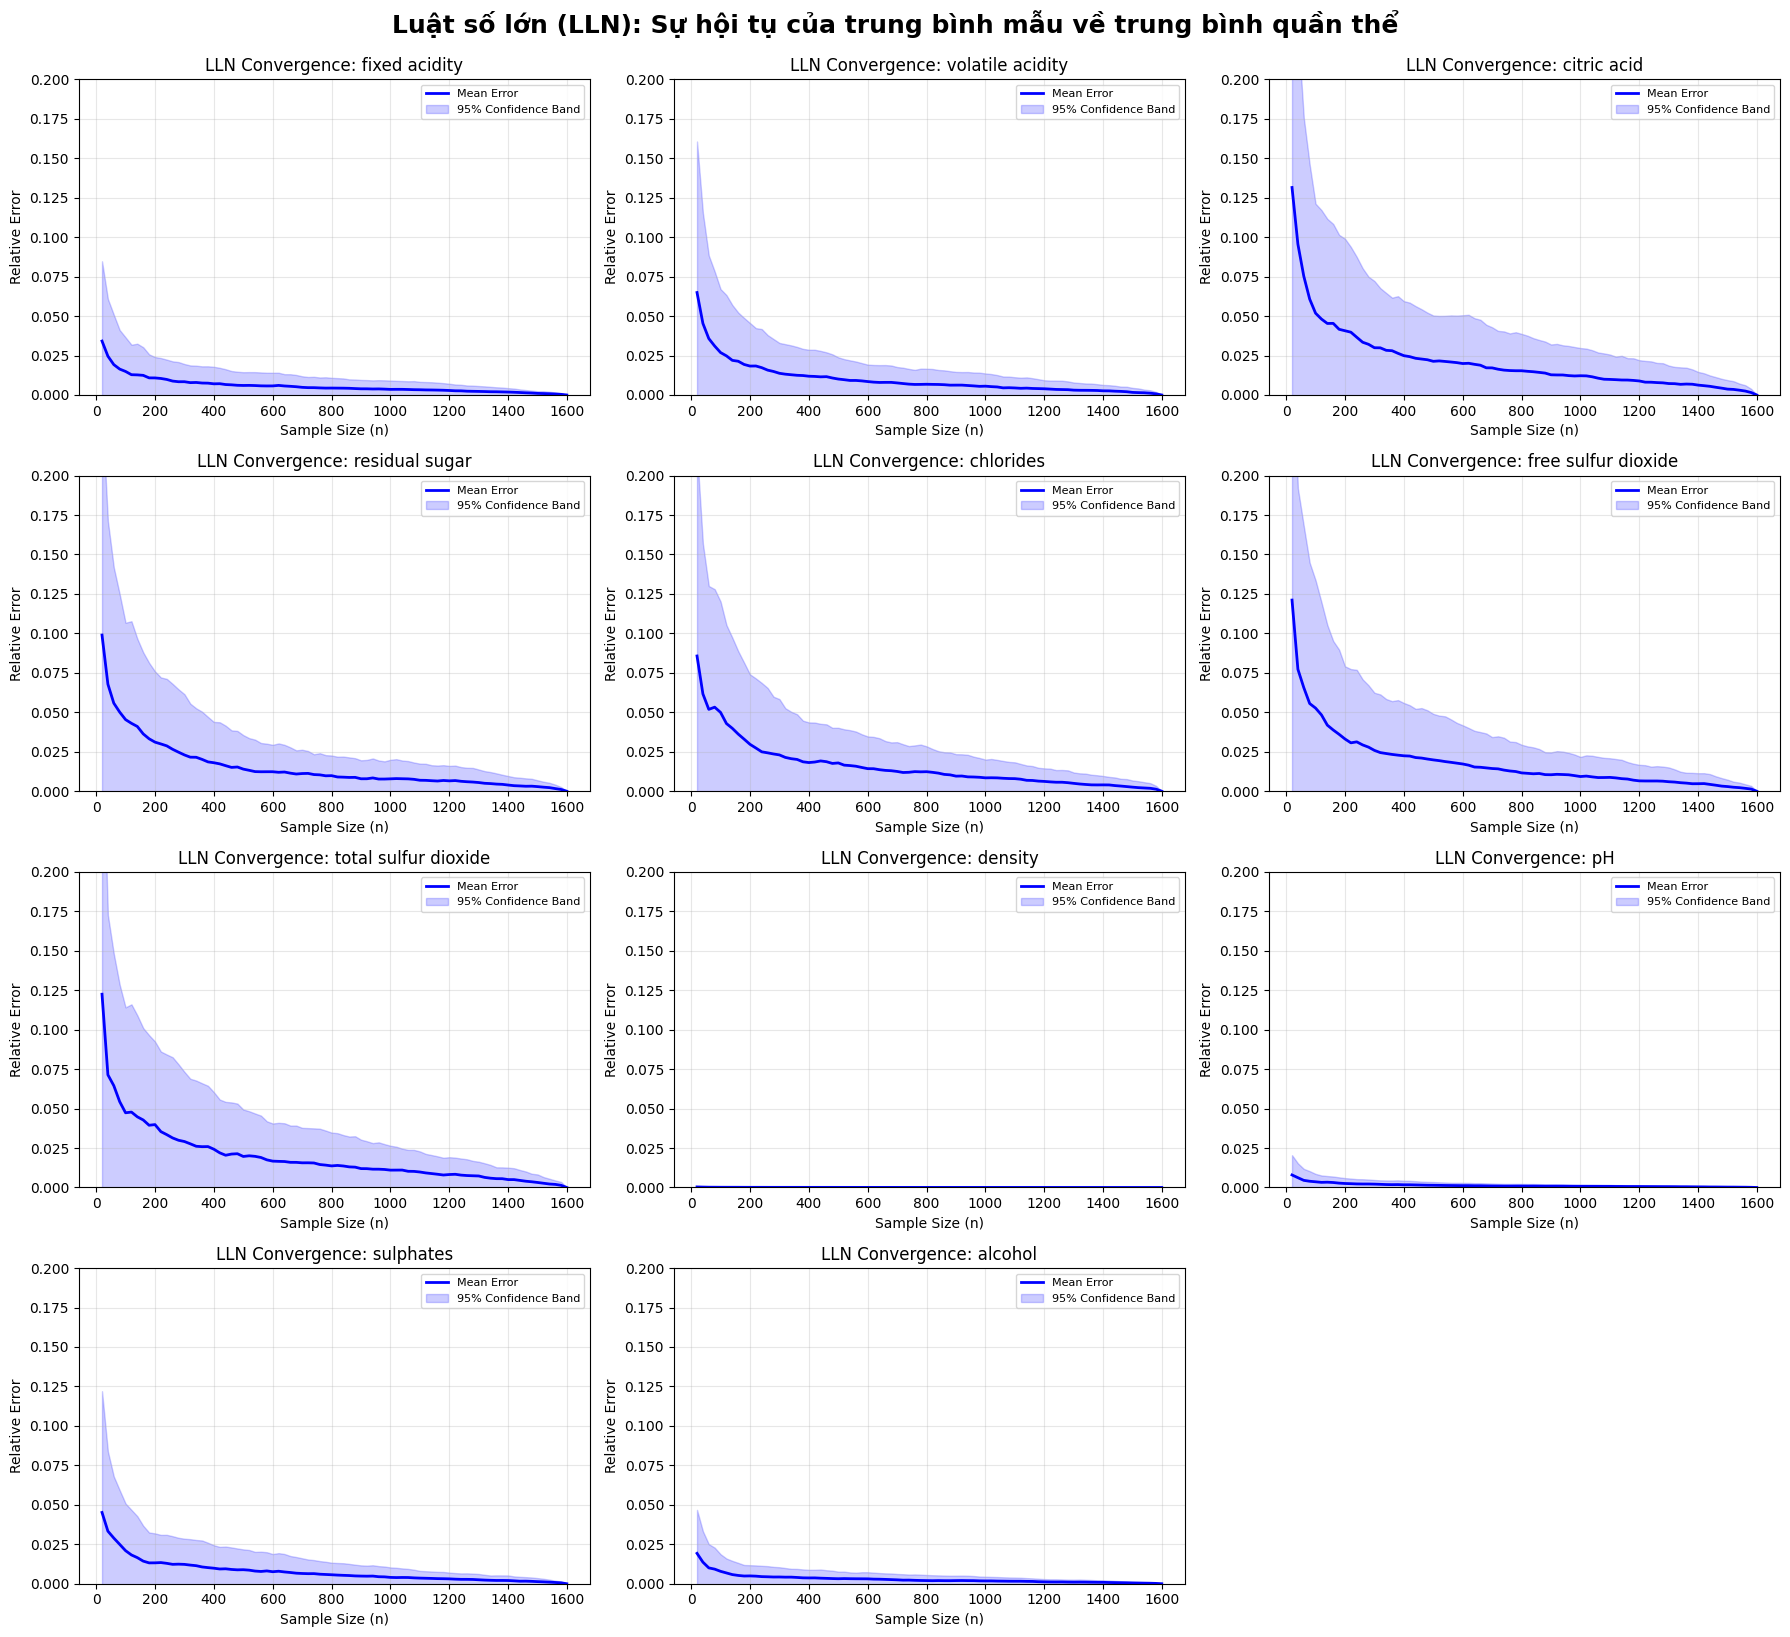

In [ ]:
# Vẽ lưới biểu đồ cho tất cả 11 biến
plot_lln_convergence_grid(all_trials_errors, sizes)

**LLN hoạt động đúng với tất cả 11 biến.** Đường Mean Error của mọi biến đều giảm đơn điệu về $0$ khi $n$ tăng — đúng với phát biểu $\bar{x}_n \xrightarrow{P} \mu$ khi $n \rightarrow \infty$.

**Tốc độ hội tụ khác nhau giữa các biến**, và sự khác biệt này liên quan trực tiếp đến độ lệch chuẩn $\sigma$ của từng biến. Biến có $\sigma$ lớn so với $\mu$ (hệ số biến thiên $\sigma/\mu$ cao) có trung bình mẫu dao động nhiều hơn, dẫn đến hội tụ chậm hơn. Cụ thể:

- `total sulfur dioxide`, `free sulfur dioxide`, `residual sugar`, `citric acid` có đường sai số bắt đầu cao (trên $0.10$–$0.15$) và cần $n$ lớn hơn để giảm xuống gần $0$ — phản ánh $\sigma/\mu$ lớn của các biến này.
- `density`, `pH` hội tụ rất nhanh ngay từ $n$ nhỏ, đường sai số gần như phẳng sau $n \approx 100$ — do $\sigma/\mu$ của hai biến này rất nhỏ, trung bình mẫu ít biến động.

**Confidence band hẹp dần khi $n$ tăng** ở tất cả các biến, phản ánh $\text{Var}(\bar{x}_n) = \sigma^2/n$ giảm theo $n$. Band rộng ở vùng $n$ nhỏ cho thấy kết quả không ổn định và phụ thuộc nhiều vào thứ tự lấy mẫu — đây là lý do cần lặp 100 lần thay vì chỉ chạy một lần duy nhất.

## 3. Central Limit Theorem - CLT

### 3.1 Tóm tắt lý thuyết
- **Phát biểu:** Cho dãy các biến ngẫu nhiên độc lập cùng phân phối có trung bình $\mu$ và phương sai $\sigma^2$ hữu hạn. Khi $n$ đủ lớn ($n \to \infty$), phân phối của trung bình mẫu $\bar{x}_n$ sẽ xấp xỉ phân phối chuẩn:
  $$\bar{x}_n \xrightarrow{d} \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right)$$
  Hay dạng chuẩn hóa (Z-score):
  $$Z = \frac{\bar{x}_n - \mu}{\sigma/\sqrt{n}} \xrightarrow{d} \mathcal{N}(0, 1)$$
- **Điều kiện:** Thông thường $n \geq 30$ được coi là đủ lớn để xấp xỉ chuẩn tốt cho hầu hết các phân phối. Với các phân phối lệch nhiều, $n$ cần lớn hơn.

### 3.2 Ảnh hưởng của $n$ — So sánh quá trình hội tụ
Chúng ta sẽ lấy mẫu với các kích thước $n \in \{5, 10, 30, 50, 100\}$. Với mỗi $n$, thực hiện 1000 lần lấy mẫu để vẽ phân phối của $\bar{x}$.

In [ ]:
np.random.seed(42)
sample_sizes = [5, 10, 30, 50, 100]
n_trials = 1000

# Thực hiện mô phỏng CLT
clt_results = simulate_clt(features, sample_sizes=sample_sizes, n_trials=n_trials)

display(Markdown(f"#### **Mô phỏng CLT hoàn tất với {n_trials} trials cho mỗi kích thước mẫu $n$.**"))

#### **Mô phỏng CLT hoàn tất với 1000 trials cho mỗi kích thước mẫu $n$.**

### 3.3 Trực quan hóa CLT hội tụ

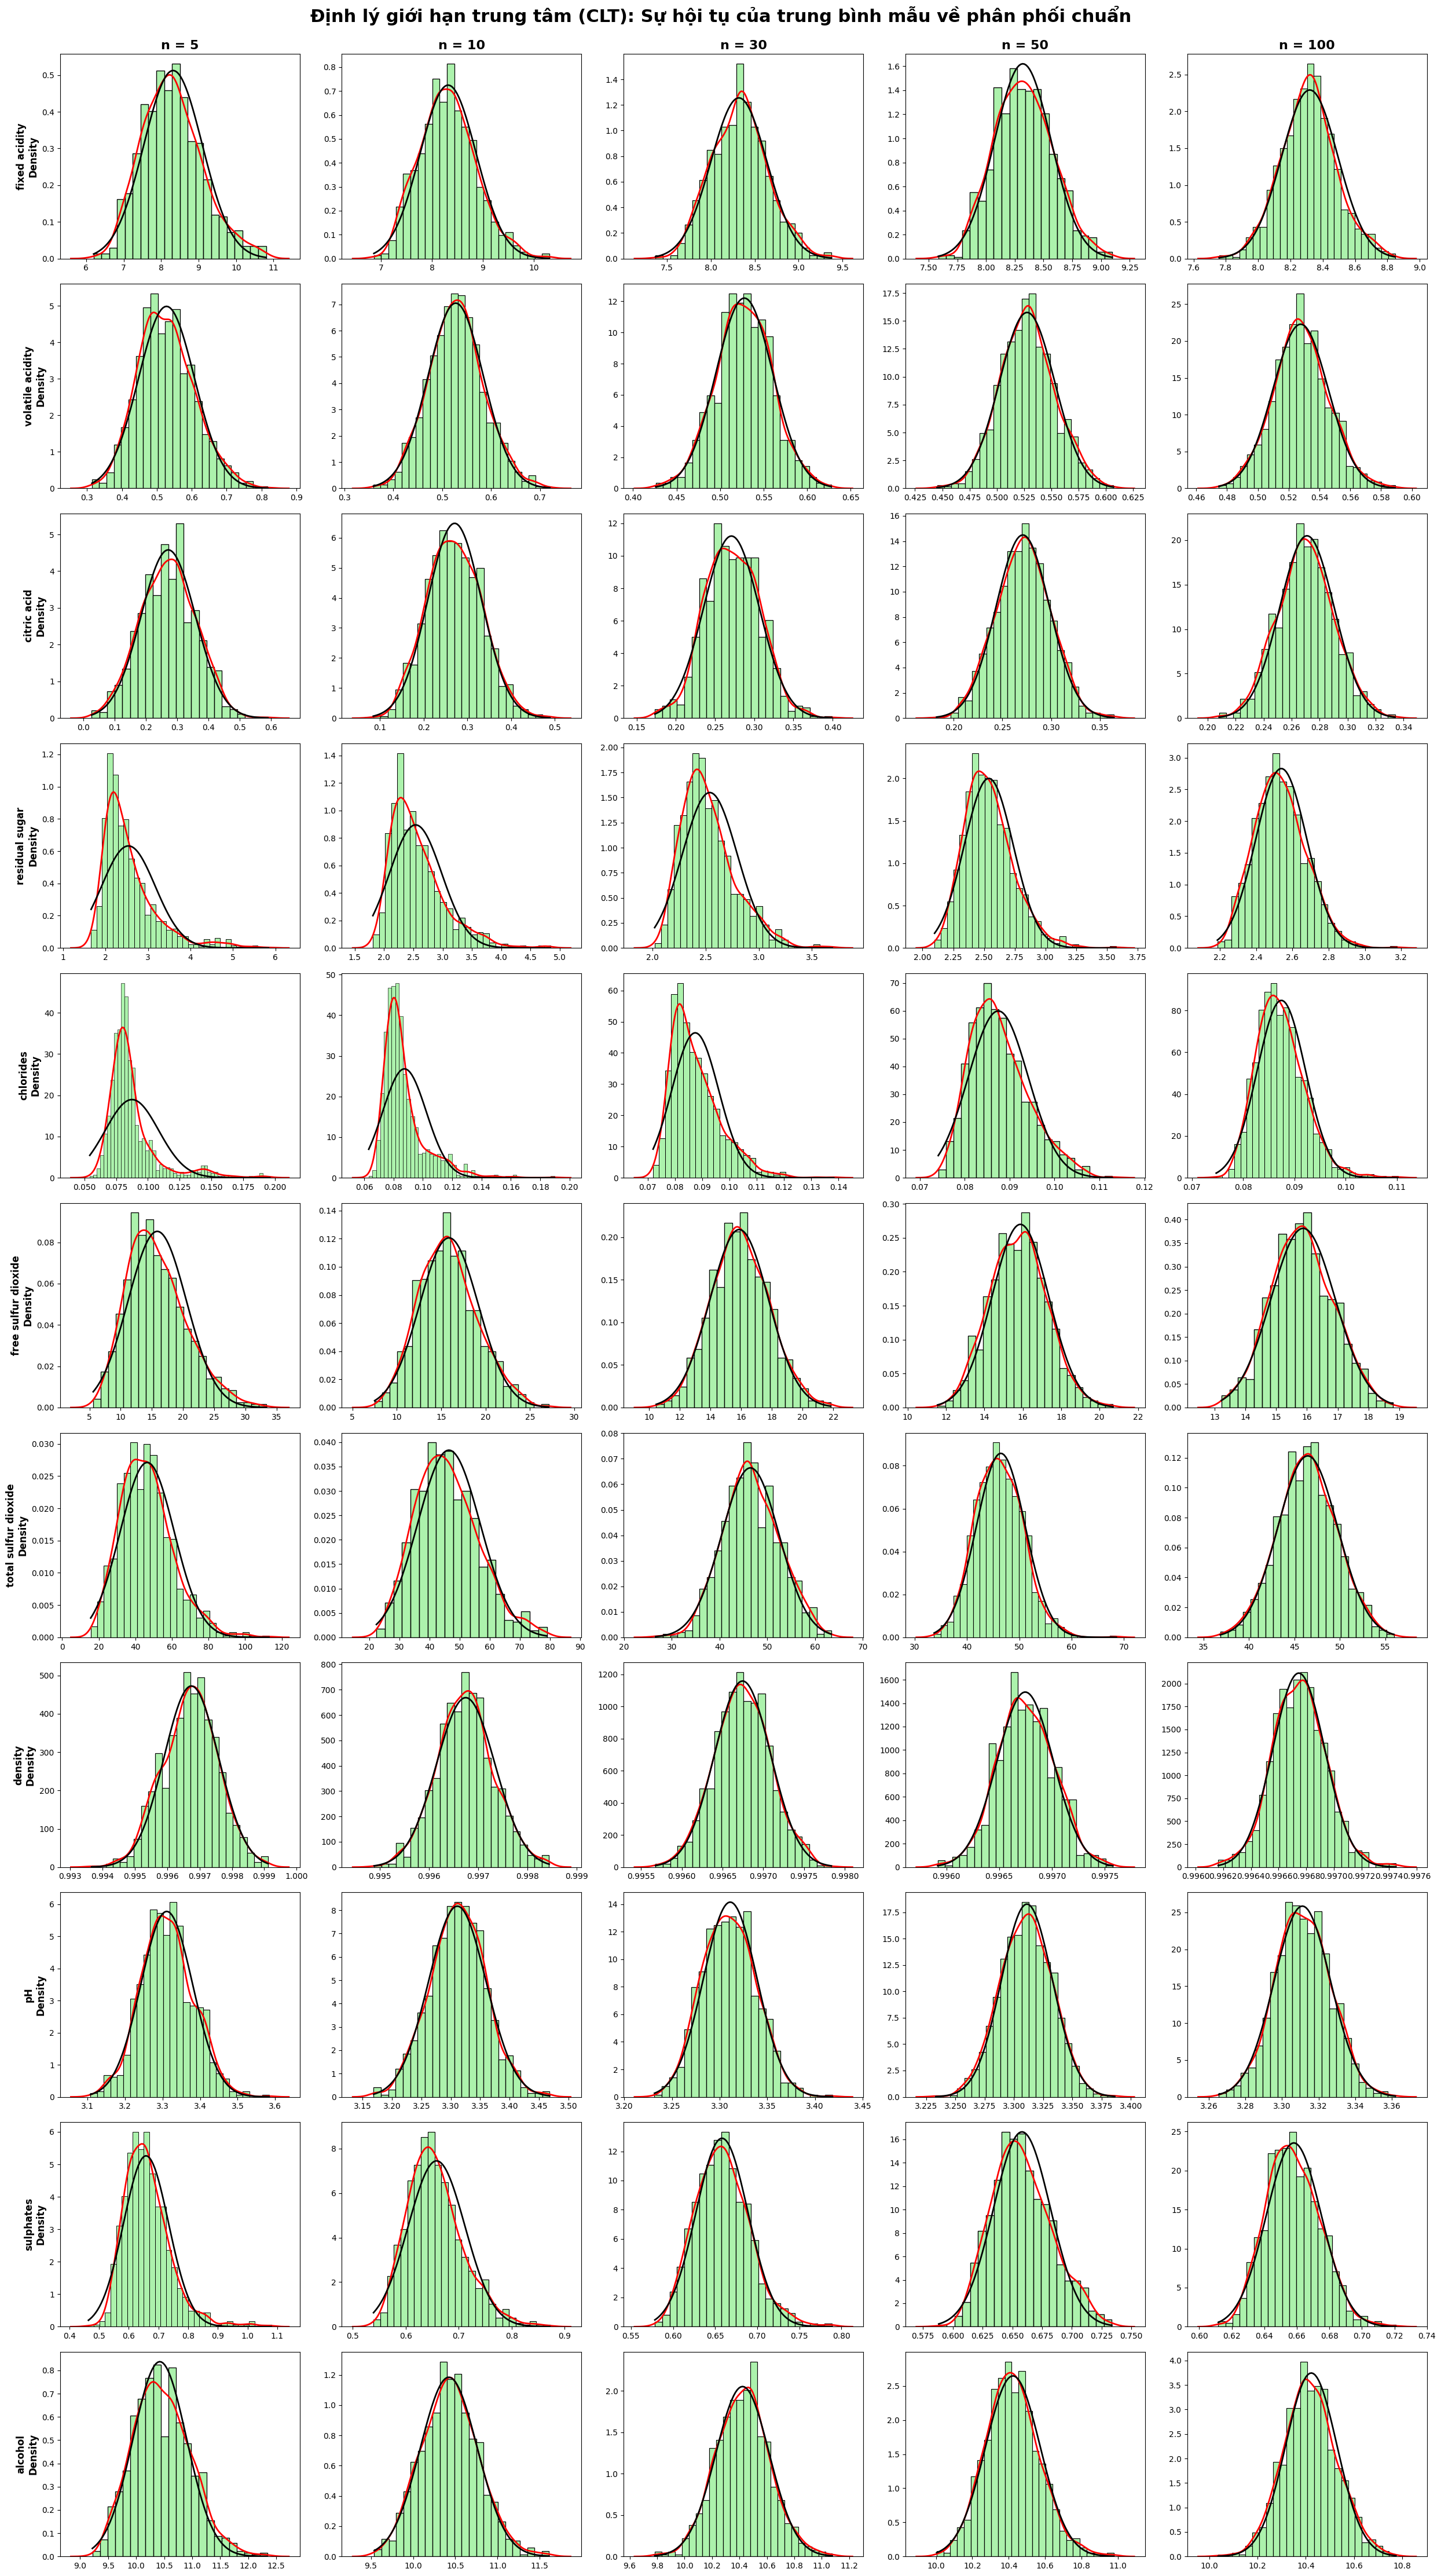

In [ ]:
# Vẽ lưới biểu đồ hội tụ chuẩn cho tất cả các biến
plot_clt_convergence_grid(clt_results, sample_sizes, pop_means, pop_stds)

**CLT hoạt động đúng với tất cả 11 biến.** Khi $n$ tăng từ $5$ lên $100$, histogram của $\bar{x}$ ở mọi biến đều hội tụ dần về dạng chuẩn $\mathcal{N}(\mu, \sigma^2/n)$ — đúng với phát biểu của CLT, bất kể phân phối gốc của biến đó có hình dạng như thế nào.

**Tốc độ hội tụ phụ thuộc vào độ lệch của phân phối gốc.** Quan sát rõ nhất ở hai nhóm:

- `density`, `pH`, `fixed acidity`, `volatile acidity`: Histogram đã khá chuẩn ngay từ $n = 5$–$10$ vì phân phối gốc của các biến này tương đối đối xứng, ít lệch.
- `residual sugar`, `chlorides`: Phân phối gốc lệch phải rõ rệt, nên ở $n = 5$ histogram của $\bar{x}$ vẫn còn lệch và có đuôi phải dài. Phải đến $n = 30$–$50$ histogram mới bắt đầu khớp tốt với đường chuẩn lý thuyết.

**Đường chuẩn lý thuyết $\mathcal{N}(\mu, \sigma^2/n)$ khớp tốt with histogram thực nghiệm** ở hầu hết các biến khi $n \geq 30$, xác nhận rằng ngưỡng $n \geq 30$ thường được dùng trong thực tế là hợp lý — ngoại trừ các biến có độ lệch cao như `residual sugar` và `chlorides` cần $n$ lớn hơn để đạt xấp xỉ tốt.

#### ***Chuẩn hóa về Z-score***
Ngoài ra ta có thể chuyển đổi trung bình mẫu $\bar{x}$ về $Z = \frac{\bar{x} - \mu}{\sigma/\sqrt{n}}$ để đưa tất cả các biến về cùng một thang đo $\mathcal{N}(0, 1)$, sau đó chồng chúng lại để quan sát rõ hơn. Chúng ta sẽ quan sát tại $n=100$.

**Note:** Đây chỉ là một cách trực quan hóa thay thế — đưa tất cả biến về cùng thang đo để dễ so sánh, không bổ sung thêm bằng chứng mới so với phần trên.

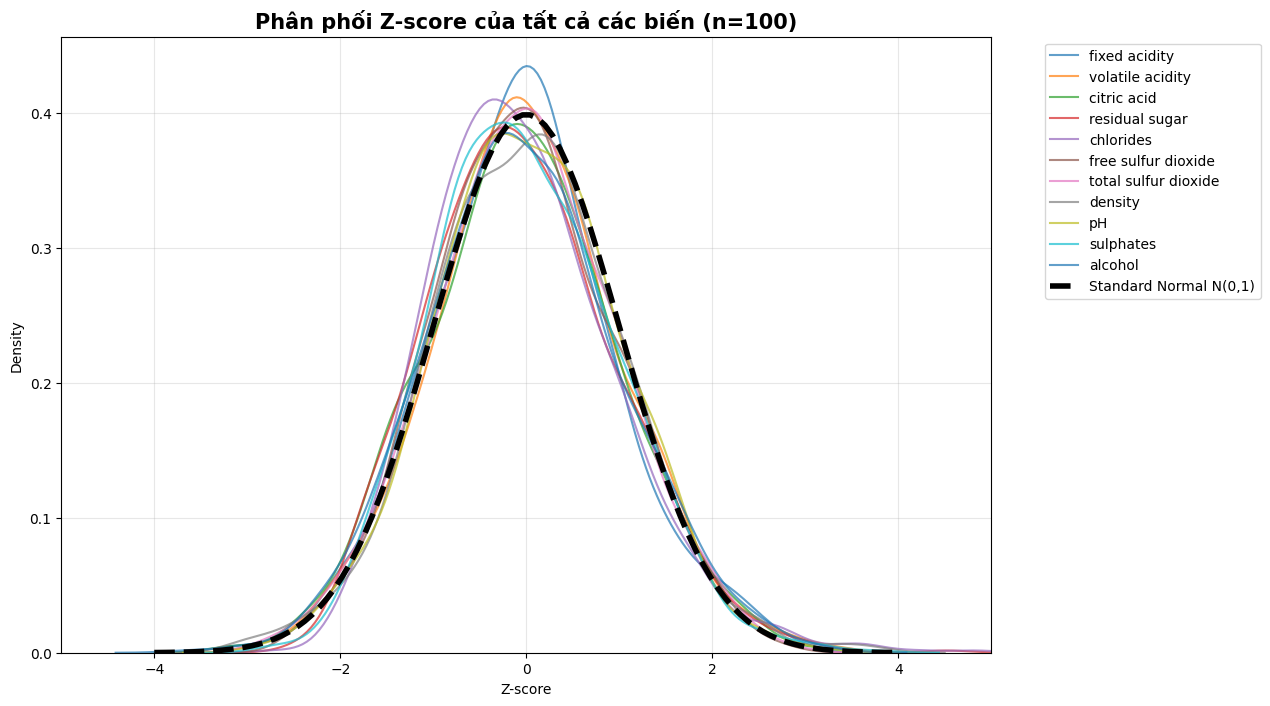

In [ ]:
n_fixed = 100
plt.figure(figsize=(12, 8))

for col in features.columns:
    means = np.array(clt_results[col][n_fixed])
    z_scores = (means - pop_means[col]) / (pop_stds[col] / np.sqrt(n_fixed))
    sns.kdeplot(z_scores, label=col, alpha=0.7)

x_norm = np.linspace(-4, 4, 100)
plt.plot(x_norm, stats.norm.pdf(x_norm, 0, 1), color='black', lw=4, ls='--', label='Standard Normal N(0,1)')

plt.title(f"Phân phối Z-score của tất cả các biến (n={n_fixed})", fontsize=15, fontweight='bold')
plt.xlabel("Z-score")
plt.ylabel("Density")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(-5, 5)
plt.show()

Tại $n = 100$, đường KDE của tất cả 11 biến đều **bám sát đường $\mathcal{N}(0,1)$** (đường đứt đen), xác nhận lại kết quả CLT trên toàn bộ dataset. Hai ngoại lệ nhỏ là `fixed acidity` có đỉnh cao hơn và `chlorides` có đỉnh hơi lệch sang trái một chút so với $\mathcal{N}(0,1)$. Còn lại bám khá sát.